# Credit Risk Research Analysis
**XAI · Surrogate Tree · Calibration**

This notebook loads models trained in `model.ipynb` and implements
the publishable research pipeline:

1. Secondary task `y_bad` (late + default)
2. SHAP feature attributions & permutation importance
3. Surrogate decision tree (auditable global rules)
4. Model calibration (Brier score, ECE, post-hoc isotonic calibration)


## 1. Setup

In [1]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

# Ensure Graphviz executable is visible to this running kernel
graphviz_bin = r'C:\Program Files\Graphviz\bin'
if os.path.exists(os.path.join(graphviz_bin, 'dot.exe')) and graphviz_bin not in os.environ.get('PATH', ''):
    os.environ['PATH'] = graphviz_bin + os.pathsep + os.environ.get('PATH', '')

from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, brier_score_loss,
    r2_score, mean_absolute_error,
)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.model_selection import train_test_split

from seqcredit_model.credit_model import (
    CreditRiskDataLoader, LogisticRegressionModel,
    XGBoostModel, RandomForestModel, LightGBMModel,
    LSTMModel, HybridLSTMModel, set_random_seeds,
)

set_random_seeds(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
print('Setup complete.')
print('Graphviz dot available:', os.path.exists(os.path.join(graphviz_bin, 'dot.exe')))


Setup complete.
Graphviz dot available: True


## 2. Data Preparation & Model Loading

In [2]:
# Static data (same deterministic split as training notebook)
loader = CreditRiskDataLoader(
    features_path=os.path.join(project_root, 'data/user_features.csv'),
    summaries_path=os.path.join(project_root, 'data/user_labels.csv'),
    transactions_dir=os.path.join(project_root, 'data/user_transactions'),
)
static_data = loader.prepare_static_splits()
X_train_scaled = static_data['X_train_scaled']
X_test_scaled  = static_data['X_test_scaled']
y_train        = static_data['y_train']   # y_default
y_test         = static_data['y_test']    # y_default
feature_names  = static_data['feature_names']

print(f'Static train: {X_train_scaled.shape}, test: {X_test_scaled.shape}')
print(f'y_default rate — train: {y_train.mean():.4f}, test: {y_test.mean():.4f}')


[DataLoader] Validation passed: 10,000 matching users, label values=[np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Static train: (4867, 38), test: (1217, 38)
y_default rate — train: 0.1253, test: 0.1249


In [3]:
# LSTM arrays saved by training notebook
lstm_arrays = np.load(os.path.join(project_root, 'data', 'lstm_test_arrays.npz'))
X_train_seq         = lstm_arrays['X_train_seq']
X_test_seq          = lstm_arrays['X_test_seq']
X_train_static_lstm = lstm_arrays['X_train_static']
X_test_static_lstm  = lstm_arrays['X_test_static']
y_train_lstm        = lstm_arrays['y_train']
y_test_lstm         = lstm_arrays['y_test']

print(f'LSTM train seq: {X_train_seq.shape}, test seq: {X_test_seq.shape}')
assert len(y_test_lstm) == len(y_test), 'Test set size mismatch'
print('Test set alignment confirmed.')


LSTM train seq: (4867, 100, 38), test seq: (1217, 100, 38)
Test set alignment confirmed.


In [4]:
# Load all 6 saved models
models_dir = os.path.join(project_root, 'models')

lr_model     = LogisticRegressionModel.load(os.path.join(models_dir, 'lr_model.pkl'))
xgb_model    = XGBoostModel.load(os.path.join(models_dir, 'xgb_model.pkl'))
rf_model     = RandomForestModel.load(os.path.join(models_dir, 'rf_model.pkl'))
lgbm_model   = LightGBMModel.load(os.path.join(models_dir, 'lgbm_model.pkl'))
lstm_model   = LSTMModel.load(os.path.join(models_dir, 'lstm_model.keras'))
hybrid_model = HybridLSTMModel.load(os.path.join(models_dir, 'hybrid_model.keras'))

print('All 6 models loaded successfully.')


All 6 models loaded successfully.


## 3. Secondary Target: `y_bad` (Late + Default)

The primary task (`y_default`) flags only full defaults.  
`y_bad = 1` for **any bad outcome** — late payers (`label=1`) *and* defaulters (`label=2`).  
Evaluating all models on both targets reveals whether the models also detect late-payment risk.


In [5]:
# Build y_bad aligned to the same test/train sets as static_data
df_labels   = pd.read_csv(os.path.join(project_root, 'data', 'user_labels.csv'))
df_features = pd.read_csv(os.path.join(project_root, 'data', 'user_features.csv'))
df_all = df_features.merge(df_labels, on='user_id', how='inner')
df_all = df_all[df_all['credit_risk_label'] != -1].copy()
df_all['y_bad'] = df_all['credit_risk_label'].isin([1, 2]).astype(int)

# Align to the exact user order stored by loader after prepare_static_splits()
uid_to_ybad  = dict(zip(df_all['user_id'], df_all['y_bad']))
y_bad_test   = np.array([uid_to_ybad[uid] for uid in loader._test_user_ids])
y_bad_train  = np.array([uid_to_ybad[uid] for uid in loader._train_user_ids])

print(f'y_bad  rate — train: {y_bad_train.mean():.4f}, test: {y_bad_test.mean():.4f}')
print(f'y_default rate — test: {y_test.mean():.4f}  (bad is broader, should be higher)')


y_bad  rate — train: 0.4524, test: 0.4659
y_default rate — test: 0.1249  (bad is broader, should be higher)


In [6]:
# Collect model probabilities
lr_proba     = lr_model.predict_proba(X_test_scaled)
xgb_proba    = xgb_model.predict_proba(X_test_scaled)
rf_proba     = rf_model.predict_proba(X_test_scaled)
lgbm_proba   = lgbm_model.predict_proba(X_test_scaled)
lstm_proba   = lstm_model.predict_proba(X_test_seq)
hybrid_proba = hybrid_model.predict_proba(X_test_seq, X_test_static_lstm)

model_names = ['Logistic Regression', 'XGBoost', 'Random Forest',
               'LightGBM', 'Seq LSTM', 'Hybrid LSTM']
all_probas  = [lr_proba, xgb_proba, rf_proba, lgbm_proba, lstm_proba, hybrid_proba]

def evaluate(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return dict(
        AUC_ROC   = roc_auc_score(y_true, proba),
        AUC_PR    = average_precision_score(y_true, proba),
        F1        = f1_score(y_true, pred, zero_division=0),
        Precision = precision_score(y_true, pred, zero_division=0),
        Recall    = recall_score(y_true, pred, zero_division=0),
    )

rows_d, rows_b = [], []
for name, proba in zip(model_names, all_probas):
    rows_d.append({'Model': name, **evaluate(y_test_lstm, proba)})
    rows_b.append({'Model': name, **evaluate(y_bad_test,  proba)})

df_default = pd.DataFrame(rows_d).set_index('Model')
df_bad     = pd.DataFrame(rows_b).set_index('Model')

print('=== y_default (label==2) ===')
print(df_default.round(4).to_string())
print()
print('=== y_bad (label in {1,2}) ===')
print(df_bad.round(4).to_string())


=== y_default (label==2) ===
                     AUC_ROC  AUC_PR      F1  Precision  Recall
Model                                                          
Logistic Regression   0.4794  0.1232  0.1674     0.1295  0.2368
XGBoost               0.4587  0.1155  0.2177     0.1229  0.9539
Random Forest         0.4608  0.1138  0.0125     0.1250  0.0066
LightGBM              0.4927  0.1249  0.2221     0.1249  1.0000
Seq LSTM              0.5046  0.1263  0.0566     0.1000  0.0395
Hybrid LSTM           0.8627  0.6170  0.4988     0.3863  0.7039

=== y_bad (label in {1,2}) ===
                     AUC_ROC  AUC_PR      F1  Precision  Recall
Model                                                          
Logistic Regression   0.4908  0.4702  0.3053     0.4640  0.2275
XGBoost               0.5194  0.5005  0.6285     0.4653  0.9683
Random Forest         0.5192  0.4903  0.0070     0.2500  0.0035
LightGBM              0.5309  0.4924  0.6357     0.4659  1.0000
Seq LSTM              0.4797  0.4529  0.086

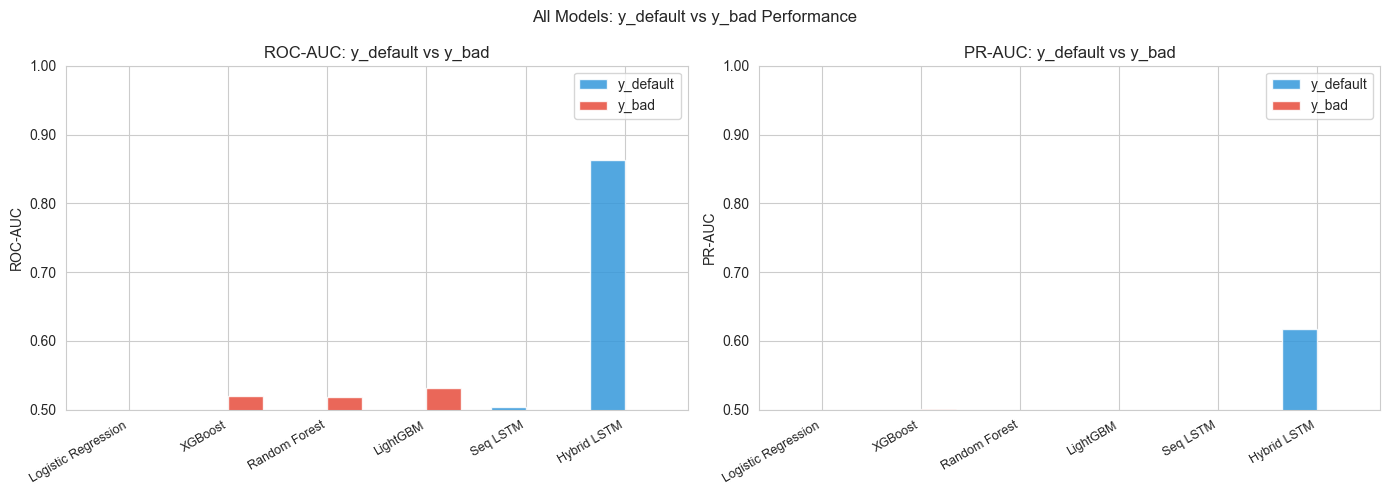

In [7]:
# Side-by-side bar chart: AUC-ROC and PR-AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(model_names))
w = 0.35
for ax, metric, title in zip(axes, ['AUC_ROC', 'AUC_PR'], ['ROC-AUC', 'PR-AUC']):
    ax.bar(x - w/2, df_default[metric], w, label='y_default', color='#3498db', alpha=0.85)
    ax.bar(x + w/2, df_bad[metric],     w, label='y_bad',     color='#e74c3c', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(f'{title}: y_default vs y_bad')
    ax.legend()
    ax.set_ylim(0.5, 1.0)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.suptitle('All Models: y_default vs y_bad Performance', fontsize=12)
plt.tight_layout()
plt.show()


## 4. XAI — Permutation Importance

Permutation importance measures how much model AUC-ROC drops when a feature is randomly shuffled.  
This is **model-agnostic** and applied to all four static models.


In [8]:
# Wrap models to expose sklearn scoring interface
class ProbaWrapper(ClassifierMixin, BaseEstimator):
    _estimator_type = "classifier"

    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        p1 = self.model.predict_proba(X)
        p1 = np.asarray(p1).reshape(-1)
        p1 = np.clip(p1, 0.0, 1.0)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def score(self, X, y):
        return roc_auc_score(y, self.predict_proba(X)[:, 1])

static_models = [
    ('Logistic Regression', lr_model),
    ('XGBoost',             xgb_model),
    ('Random Forest',       rf_model),
    ('LightGBM',            lgbm_model),
]

perm_results = {}
for name, m in static_models:
    print(f'  {name} ...')
    res = permutation_importance(
        ProbaWrapper(m), X_test_scaled, y_test_lstm,
        n_repeats=10, random_state=42, scoring='roc_auc',
    )
    perm_results[name] = res
print('Permutation importance done.')


  Logistic Regression ...
  XGBoost ...
  Random Forest ...
  LightGBM ...
Permutation importance done.


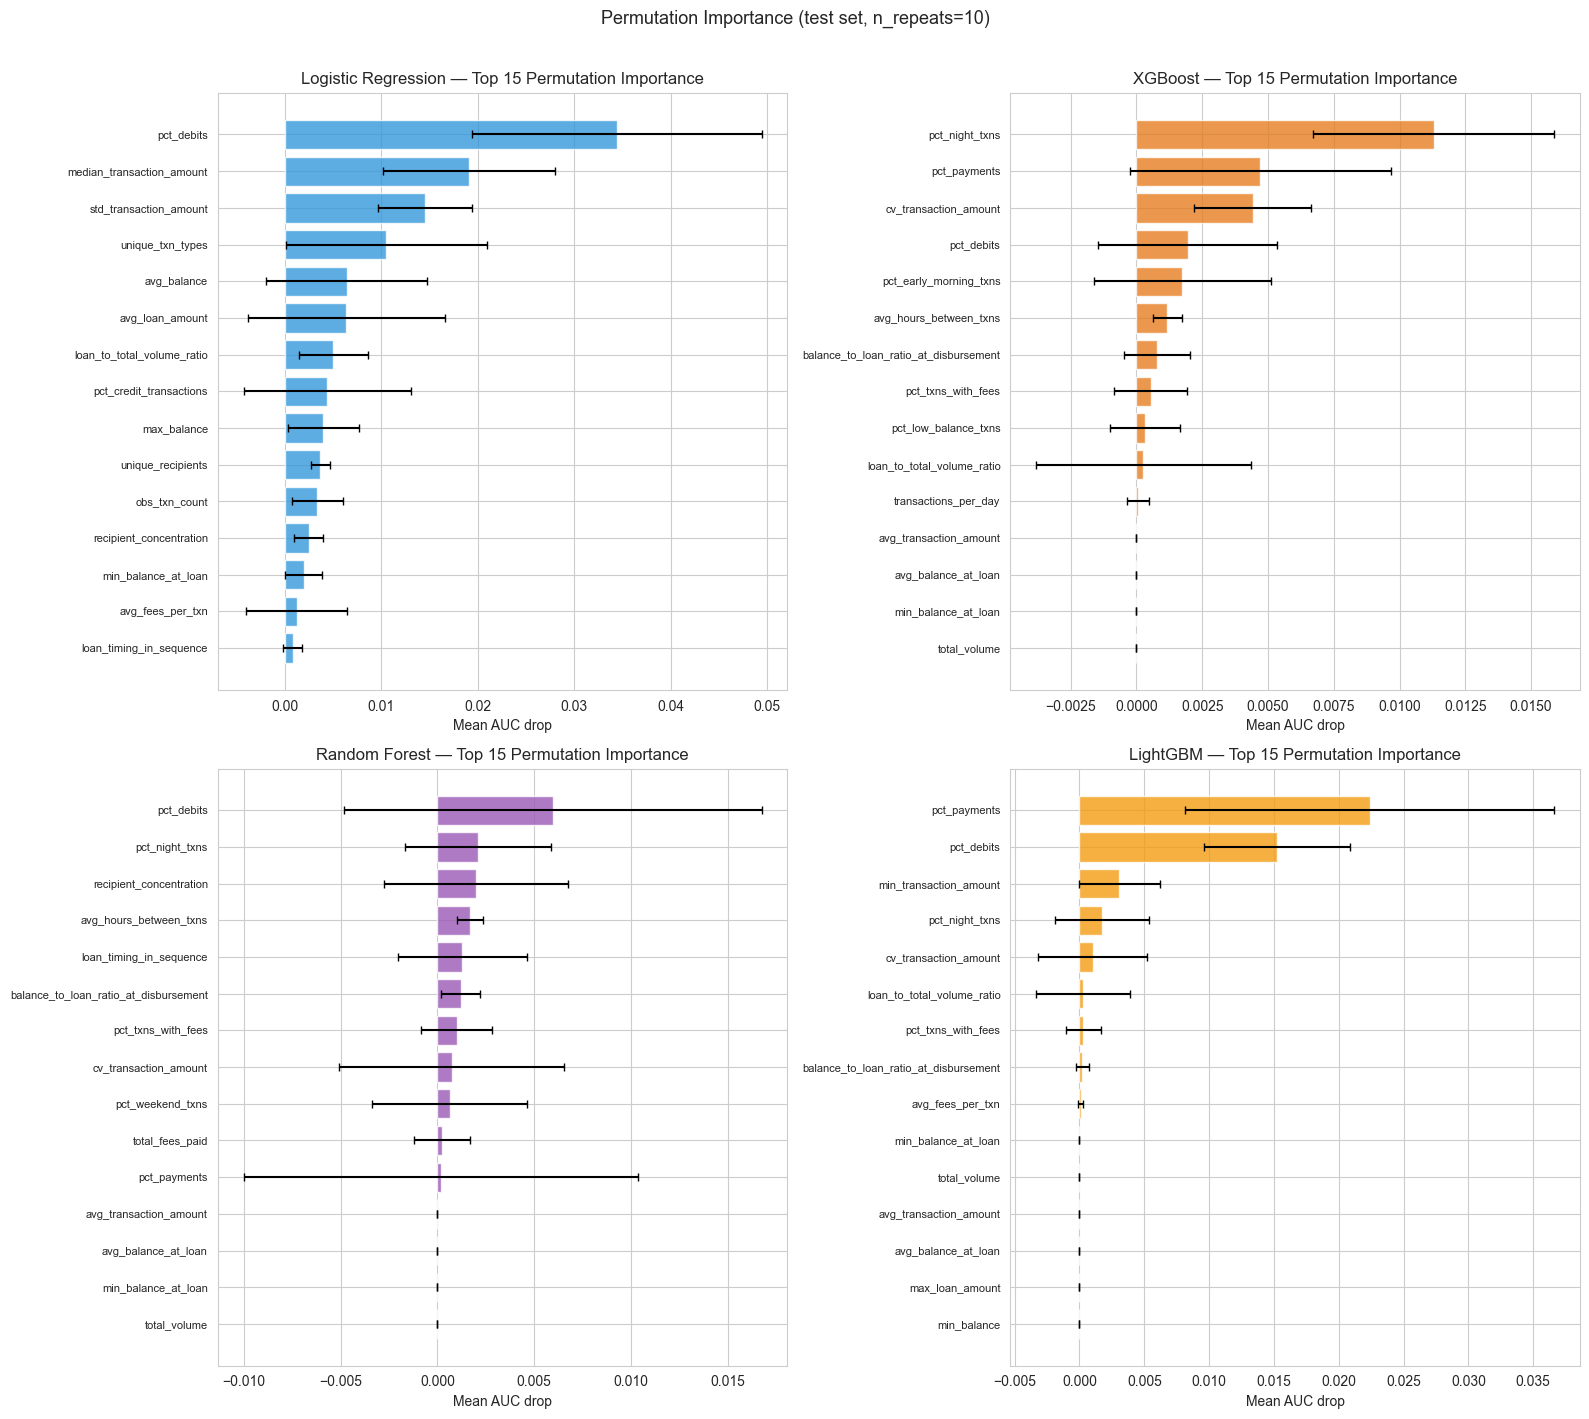

In [9]:
# Plot top-15 features per model
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
colors = ['#3498db', '#e67e22', '#9b59b6', '#f39c12']

for ax, (name, _), color in zip(axes.flat, static_models, colors):
    res   = perm_results[name]
    means = res.importances_mean
    stds  = res.importances_std
    idx   = np.argsort(means)[::-1][:15]
    ax.barh(
        range(15), means[idx][::-1], xerr=stds[idx][::-1],
        color=color, alpha=0.8, capsize=3,
    )
    ax.set_yticks(range(15))
    ax.set_yticklabels([feature_names[i] for i in idx[::-1]], fontsize=8)
    ax.set_xlabel('Mean AUC drop')
    ax.set_title(f'{name} — Top 15 Permutation Importance')

plt.suptitle('Permutation Importance (test set, n_repeats=10)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 5. XAI — SHAP Analysis

SHAP (SHapley Additive exPlanations) provides theoretically grounded, model-specific feature attributions.  
`TreeExplainer` is used for XGBoost and LightGBM (exact, computationally efficient).  
We also compare the top features between models trained on **y_default** vs **y_bad**.


XGBoost SHAP — global beeswarm (y_default):


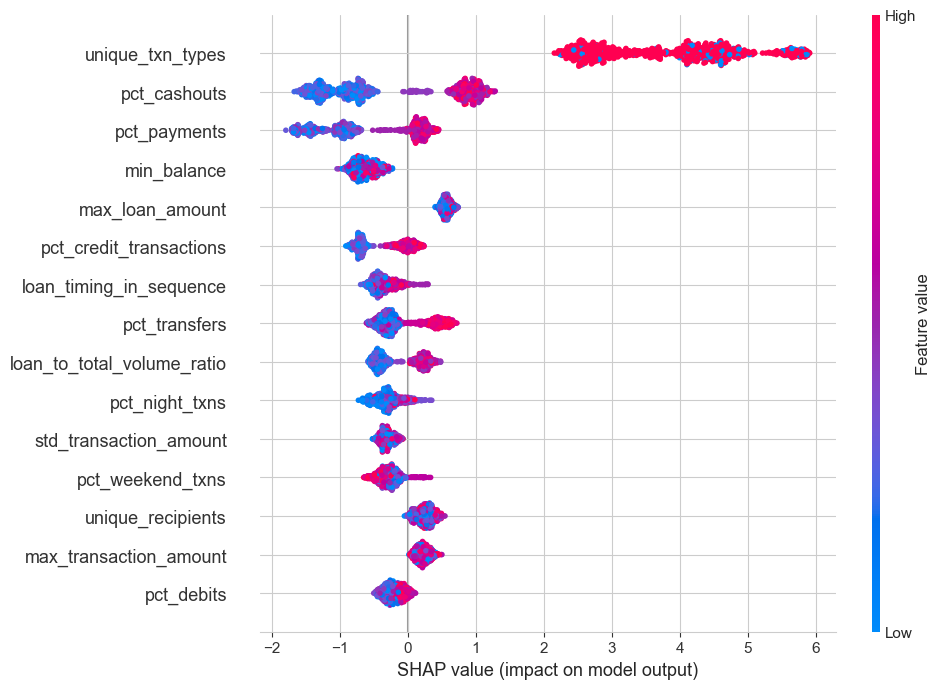

In [10]:
# SHAP for XGBoost (trained on y_default)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

explainer_xgb  = shap.TreeExplainer(xgb_model.model)
shap_xgb       = explainer_xgb.shap_values(X_test_df)
# XGBoost binary classifier returns a 2D array directly
if isinstance(shap_xgb, list):
    shap_xgb = shap_xgb[1]

print('XGBoost SHAP — global beeswarm (y_default):')
shap.summary_plot(shap_xgb, X_test_df, plot_type='dot', max_display=15,
                  show=True, plot_size=(10, 7))


LightGBM SHAP — global beeswarm (y_default):


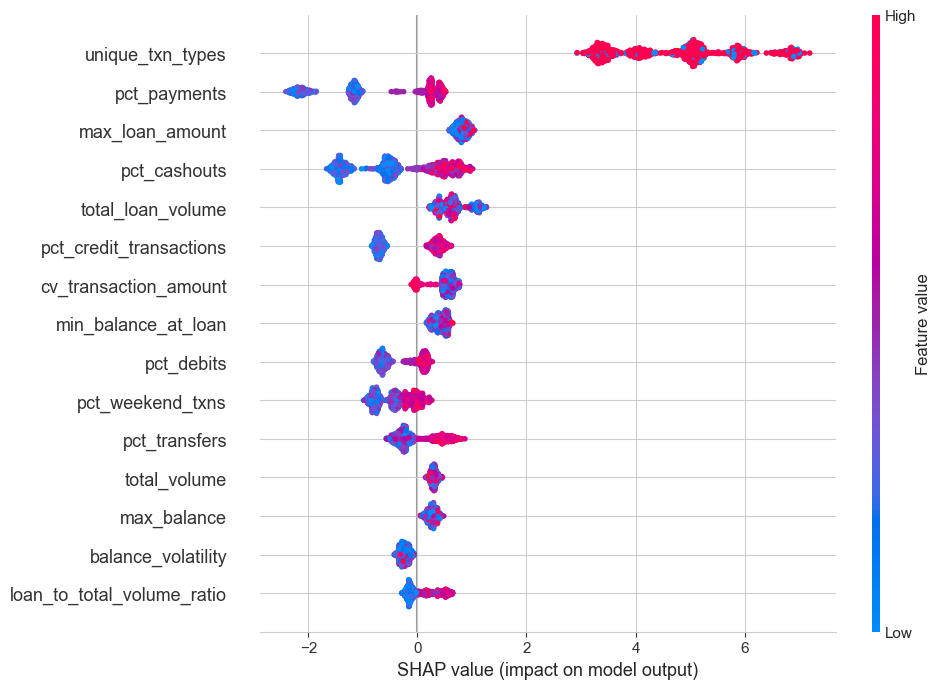

In [11]:
# SHAP for LightGBM (trained on y_default)
explainer_lgbm  = shap.TreeExplainer(lgbm_model.model)
shap_lgbm       = explainer_lgbm.shap_values(X_test_df)
if isinstance(shap_lgbm, list):
    shap_lgbm = shap_lgbm[1]

print('LightGBM SHAP — global beeswarm (y_default):')
shap.summary_plot(shap_lgbm, X_test_df, plot_type='dot', max_display=15,
                  show=True, plot_size=(10, 7))


High-risk user (index 180): predicted prob = 0.9999


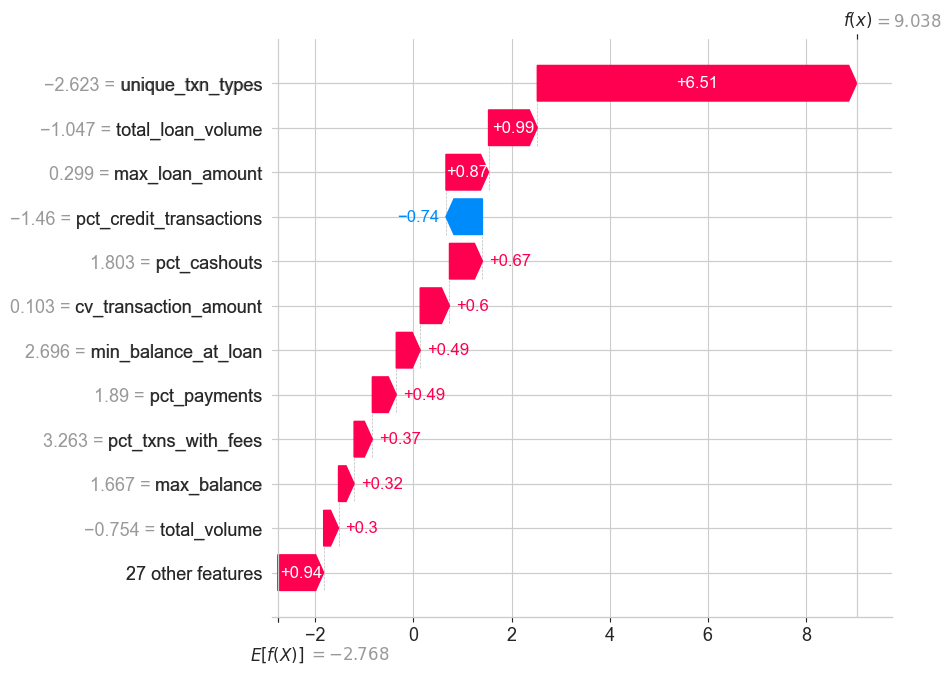

Low-risk user (index 1192): predicted prob = 0.5298


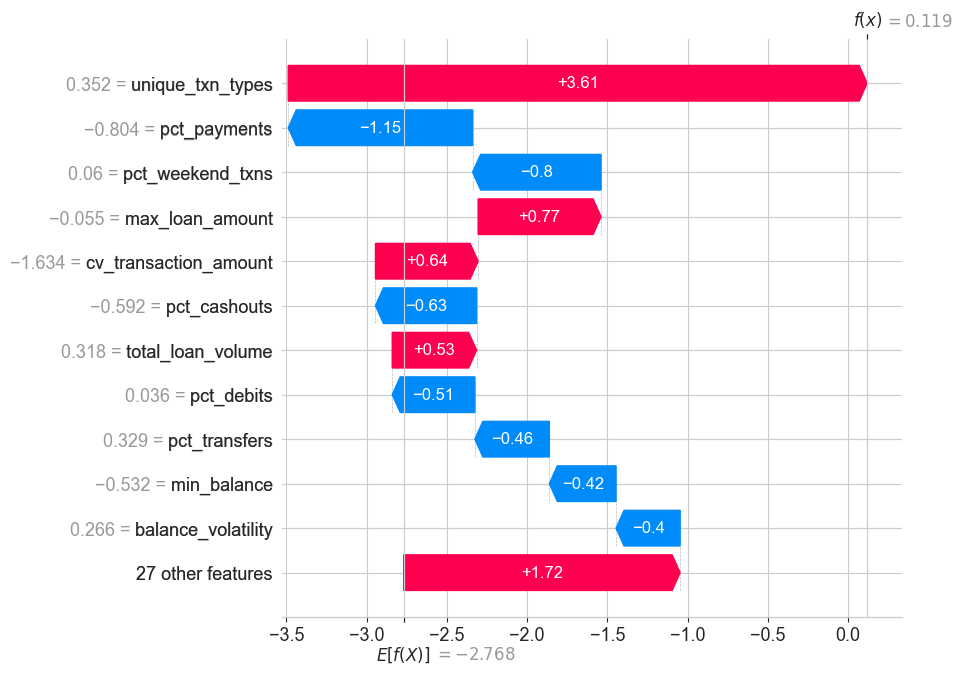

In [12]:
# Waterfall plots: high-risk and low-risk users (LightGBM)
base_val = explainer_lgbm.expected_value
if isinstance(base_val, list): base_val = base_val[1]

high_idx = int(np.argmax(lgbm_proba))
low_idx  = int(np.argmin(lgbm_proba))

for label, idx in [('High-risk', high_idx), ('Low-risk', low_idx)]:
    print(f'{label} user (index {idx}): predicted prob = {lgbm_proba[idx]:.4f}')
    exp = shap.Explanation(
        values=shap_lgbm[idx],
        base_values=base_val,
        data=X_test_df.iloc[idx],
        feature_names=feature_names,
    )
    shap.waterfall_plot(exp, max_display=12, show=True)


In [13]:
# Train a quick LightGBM on y_bad for SHAP comparison
X_tr_b, X_val_b, y_tr_b, y_val_b = train_test_split(
    X_train_scaled, y_bad_train,
    test_size=0.15, stratify=y_bad_train, random_state=42,
)
lgbm_bad = LightGBMModel(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    num_leaves=31, class_weight='balanced',
)
lgbm_bad.fit(X_tr_b, y_tr_b, X_val=X_val_b, y_val=y_val_b)

explainer_lgbm_bad = shap.TreeExplainer(lgbm_bad.model)
shap_lgbm_bad = explainer_lgbm_bad.shap_values(X_test_df)
if isinstance(shap_lgbm_bad, list):
    shap_lgbm_bad = shap_lgbm_bad[1]

print('LightGBM (y_bad) trained and SHAP computed.')


LightGBM (y_bad) trained and SHAP computed.


In [14]:
# Top-10 SHAP features comparison: y_default vs y_bad
def top_shap(shap_vals, names, k=10):
    mean_abs = np.abs(shap_vals).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:k]
    return [(names[i], float(mean_abs[i])) for i in idx]

top_d = top_shap(shap_lgbm,     feature_names)
top_b = top_shap(shap_lgbm_bad, feature_names)

cmp = pd.DataFrame({
    'Rank':            range(1, 11),
    'y_default feat':  [f for f, _ in top_d],
    'y_default |SHAP|':[round(v, 4) for _, v in top_d],
    'y_bad feat':      [f for f, _ in top_b],
    'y_bad |SHAP|':    [round(v, 4) for _, v in top_b],
})
print('Top-10 SHAP Features — LightGBM: y_default vs y_bad')
print(cmp.to_string(index=False))


Top-10 SHAP Features — LightGBM: y_default vs y_bad
 Rank          y_default feat  y_default |SHAP|              y_bad feat  y_bad |SHAP|
    1        unique_txn_types            4.7681 recipient_concentration        0.0106
    2            pct_payments            0.9857       unique_recipients        0.0067
    3         max_loan_amount            0.8198             min_balance        0.0062
    4            pct_cashouts            0.7577 pct_credit_transactions        0.0056
    5       total_loan_volume            0.6495 loan_timing_in_sequence        0.0054
    6 pct_credit_transactions            0.5465  avg_transaction_amount        0.0040
    7   cv_transaction_amount            0.5030  max_transaction_amount        0.0033
    8     min_balance_at_loan            0.4299       total_loan_volume        0.0029
    9              pct_debits            0.4167  std_transaction_amount        0.0029
   10        pct_weekend_txns            0.4086  min_transaction_amount        0.0024


## 6. Surrogate Decision Tree

A shallow decision tree trained to mimic the best-performing black-box model (LightGBM).  
**Fidelity** (R² to teacher) measures how accurately the surrogate approximates the teacher's outputs.  
The resulting tree provides human-readable, auditable decision rules.


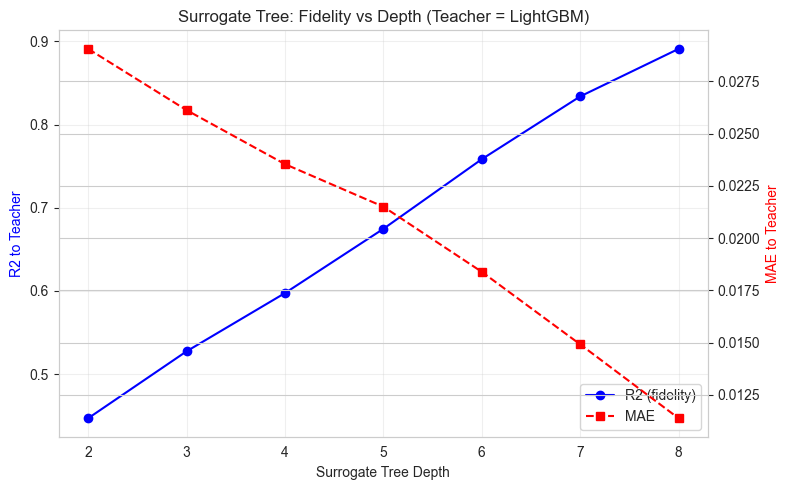

Depth | R2     | MAE
  2   | 0.4469 | 0.0291
  3   | 0.5274 | 0.0261
  4   | 0.5974 | 0.0235
  5   | 0.6746 | 0.0215
  6   | 0.7583 | 0.0184
  7   | 0.8338 | 0.0149
  8   | 0.8910 | 0.0114


In [15]:
# Fidelity curve: train surrogate at depths 2-8, measure R2 and MAE vs teacher
p_teacher = lgbm_proba

depths = list(range(2, 9))
r2s, maes = [], []

for d in depths:
    s = DecisionTreeRegressor(max_depth=d, random_state=42)
    s.fit(X_test_scaled, p_teacher)
    p_hat = s.predict(X_test_scaled)
    r2s.append(r2_score(p_teacher, p_hat))
    maes.append(mean_absolute_error(p_teacher, p_hat))

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
ax1.plot(depths, r2s,  'b-o',  label='R2 (fidelity)')
ax2.plot(depths, maes, 'r--s', label='MAE')
ax1.set_xlabel('Surrogate Tree Depth')
ax1.set_ylabel('R2 to Teacher', color='b')
ax2.set_ylabel('MAE to Teacher', color='r')
ax1.set_title('Surrogate Tree: Fidelity vs Depth (Teacher = LightGBM)')
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc='lower right')
ax1.set_xticks(depths)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Depth | R2     | MAE')
for d, r2, mae in zip(depths, r2s, maes):
    print(f'  {d}   | {r2:.4f} | {mae:.4f}')


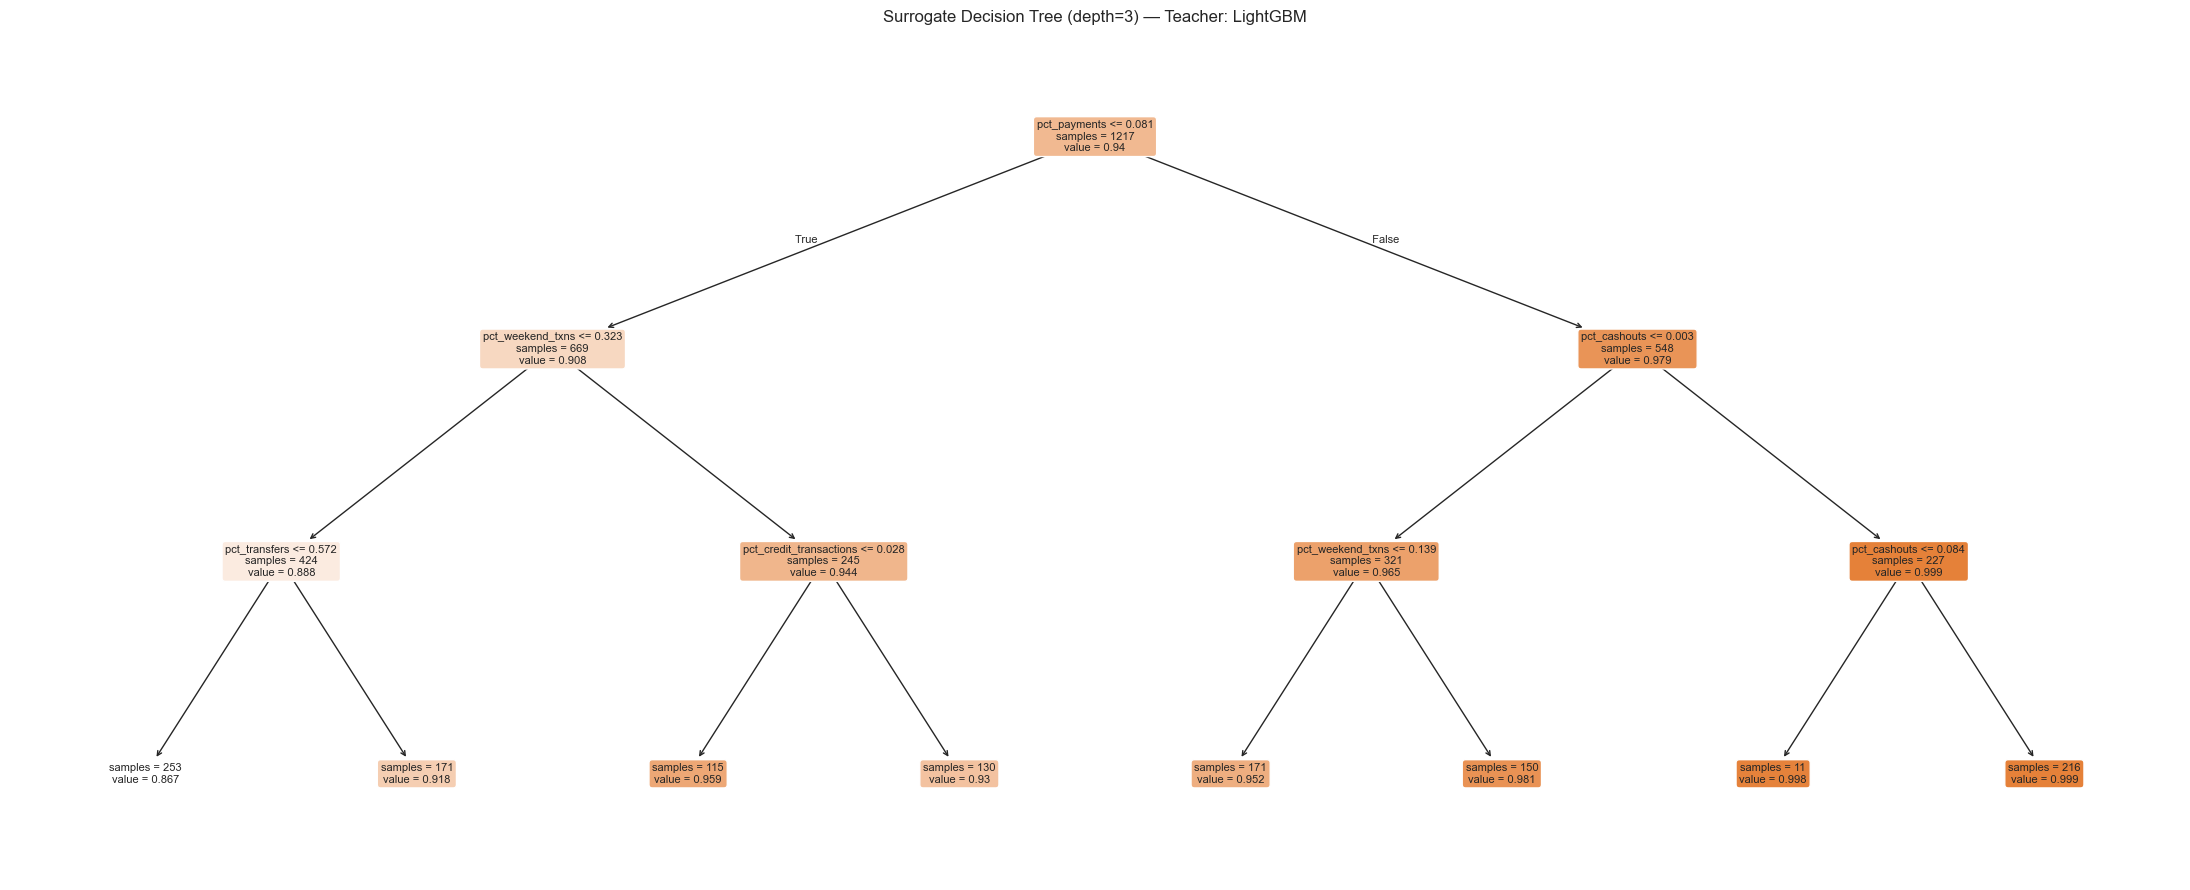

Human-readable rules:
|--- pct_payments <= 0.081
|   |--- pct_weekend_txns <= 0.323
|   |   |--- pct_transfers <= 0.572
|   |   |   |--- value: [0.867]
|   |   |--- pct_transfers >  0.572
|   |   |   |--- value: [0.918]
|   |--- pct_weekend_txns >  0.323
|   |   |--- pct_credit_transactions <= 0.028
|   |   |   |--- value: [0.959]
|   |   |--- pct_credit_transactions >  0.028
|   |   |   |--- value: [0.930]
|--- pct_payments >  0.081
|   |--- pct_cashouts <= 0.003
|   |   |--- pct_weekend_txns <= 0.139
|   |   |   |--- value: [0.952]
|   |   |--- pct_weekend_txns >  0.139
|   |   |   |--- value: [0.981]
|   |--- pct_cashouts >  0.003
|   |   |--- pct_cashouts <= 0.084
|   |   |   |--- value: [0.998]
|   |   |--- pct_cashouts >  0.084
|   |   |   |--- value: [0.999]



In [16]:
# Fit final surrogate at depth 3 — tree plot + human-readable rules
SURROGATE_DEPTH = 3
final_surrogate = DecisionTreeRegressor(max_depth=SURROGATE_DEPTH, random_state=42)
final_surrogate.fit(X_test_scaled, p_teacher)

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    final_surrogate,
    feature_names=feature_names,
    filled=True, rounded=True, fontsize=8,
    ax=ax, impurity=False, precision=3,
)
ax.set_title(
    f'Surrogate Decision Tree (depth={SURROGATE_DEPTH}) — Teacher: LightGBM',
    fontsize=12,
)
plt.tight_layout()
plt.show()

print('Human-readable rules:')
print(export_text(final_surrogate, feature_names=list(feature_names), decimals=3))


## 7. Individual Tree Visualisations

Each tree-based ensemble contains hundreds of trees; plotting one representative tree
shows the **actual split conditions and thresholds** the model has learned.

- **Random Forest**: any single  from the ensemble
- **XGBoost**: the first boosting tree (tree 0) — corrects the initial residuals
- **LightGBM**: the first leaf-wise tree — shows LGBM's depth-first leaf growth


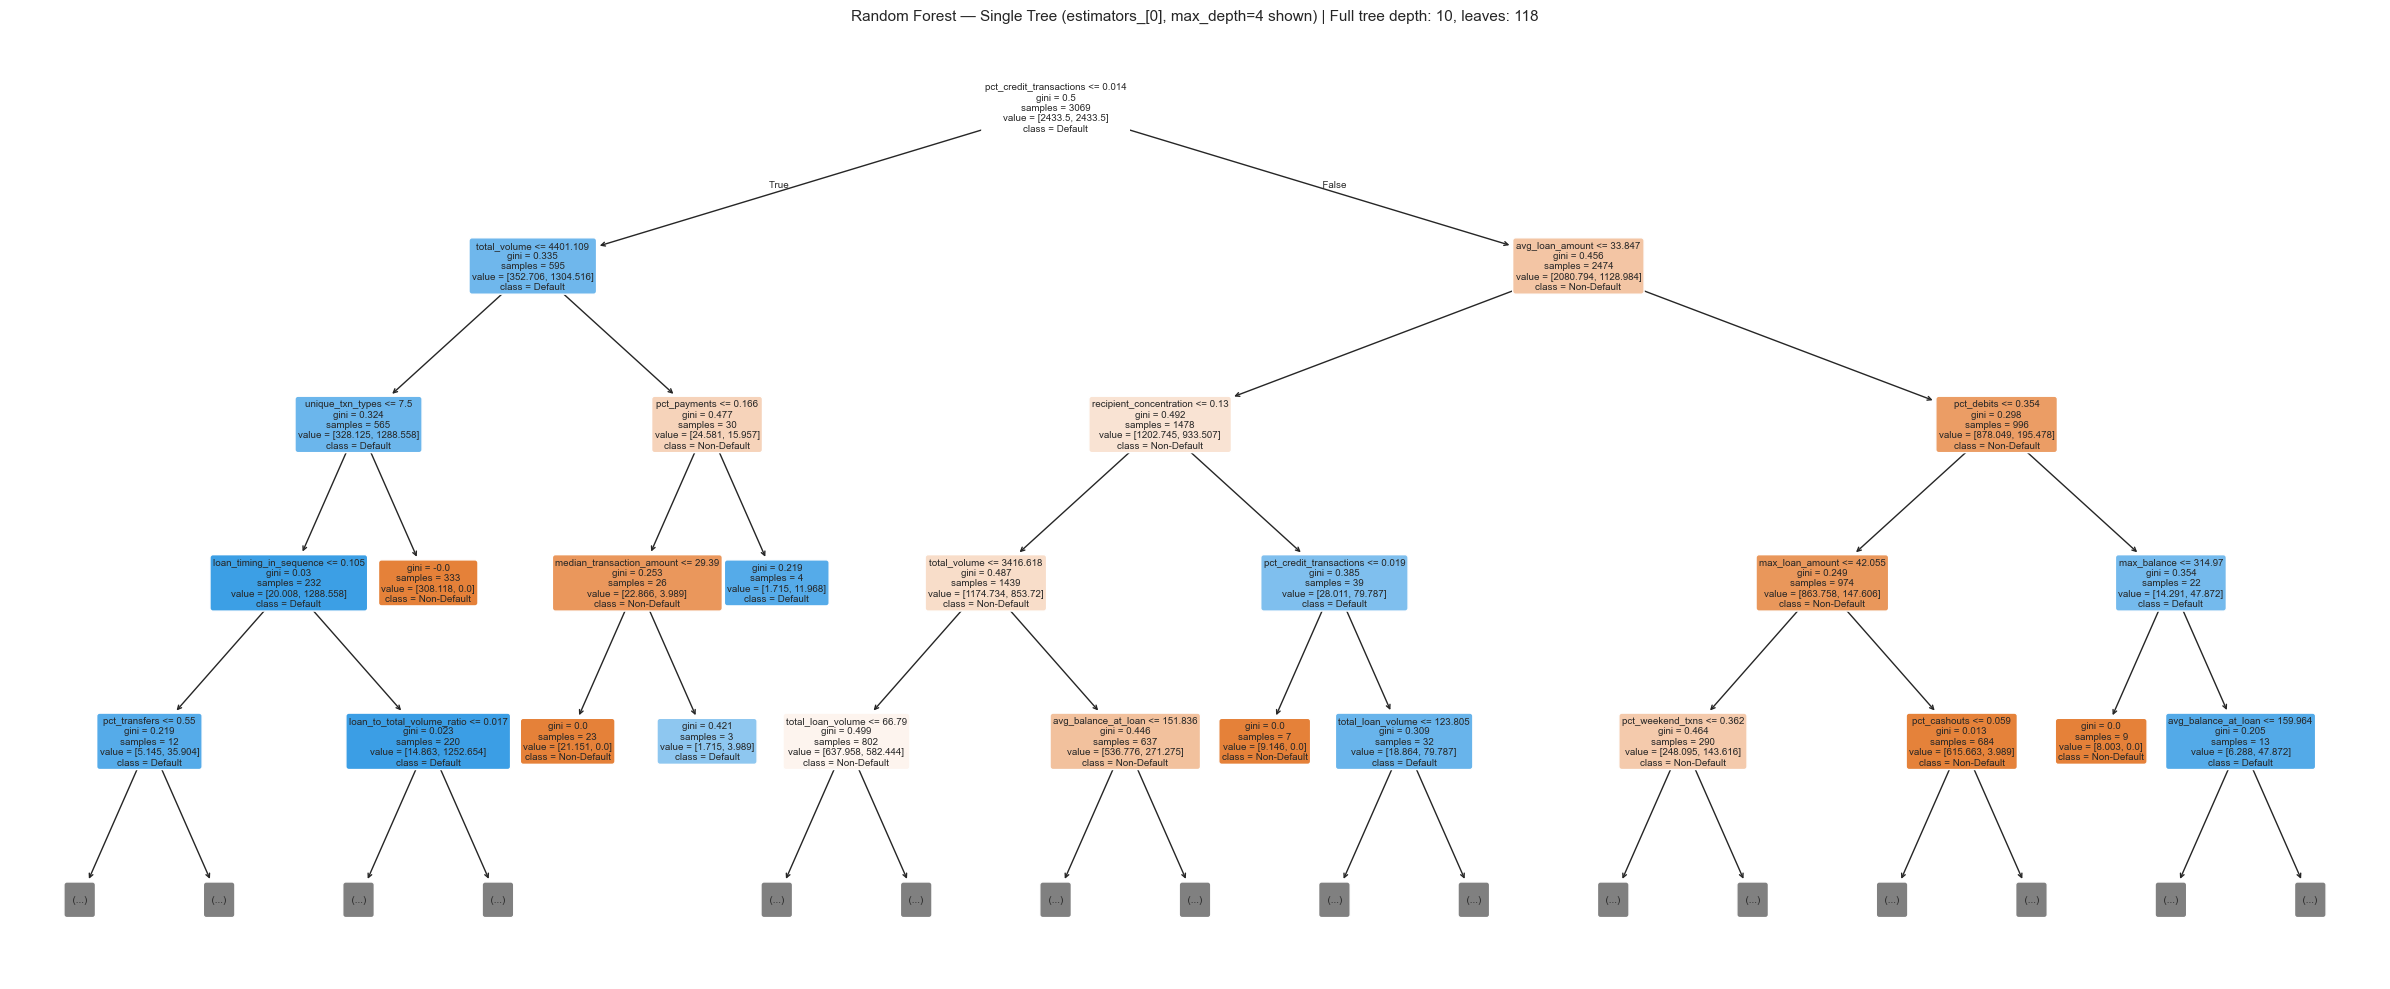

Rules (depth <= 3):
|--- pct_credit_transactions <= 0.014
|   |--- total_volume <= 4401.109
|   |   |--- unique_txn_types <= 7.500
|   |   |   |--- loan_timing_in_sequence <= 0.105
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- loan_timing_in_sequence >  0.105
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- unique_txn_types >  7.500
|   |   |   |--- class: 0.0
|   |--- total_volume >  4401.109
|   |   |--- pct_payments <= 0.166
|   |   |   |--- median_transaction_amount <= 29.390
|   |   |   |   |--- class: 0.0
|   |   |   |--- median_transaction_amount >  29.390
|   |   |   |   |--- class: 1.0
|   |   |--- pct_payments >  0.166
|   |   |   |--- class: 1.0
|--- pct_credit_transactions >  0.014
|   |--- avg_loan_amount <= 33.847
|   |   |--- recipient_concentration <= 0.130
|   |   |   |--- total_volume <= 3416.618
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- total_volume >  3416.618
|   |   |   |   |--- truncated branch of depth 7
|

In [17]:
# Random Forest — plot one tree (depth-limited to 4 for readability)
from sklearn.tree import plot_tree

single_tree = rf_model.model.estimators_[0]

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    single_tree,
    feature_names=feature_names,
    class_names=['Non-Default', 'Default'],
    filled=True, rounded=True, fontsize=7,
    max_depth=4, ax=ax, impurity=True, precision=3,
)
ax.set_title(
    f'Random Forest — Single Tree (estimators_[0], max_depth=4 shown) | '
    f'Full tree depth: {single_tree.get_depth()}, leaves: {single_tree.get_n_leaves()}',
    fontsize=11,
)
plt.tight_layout()
plt.show()

from sklearn.tree import export_text
print('Rules (depth <= 3):')
print(export_text(single_tree, feature_names=list(feature_names), max_depth=3, decimals=3))


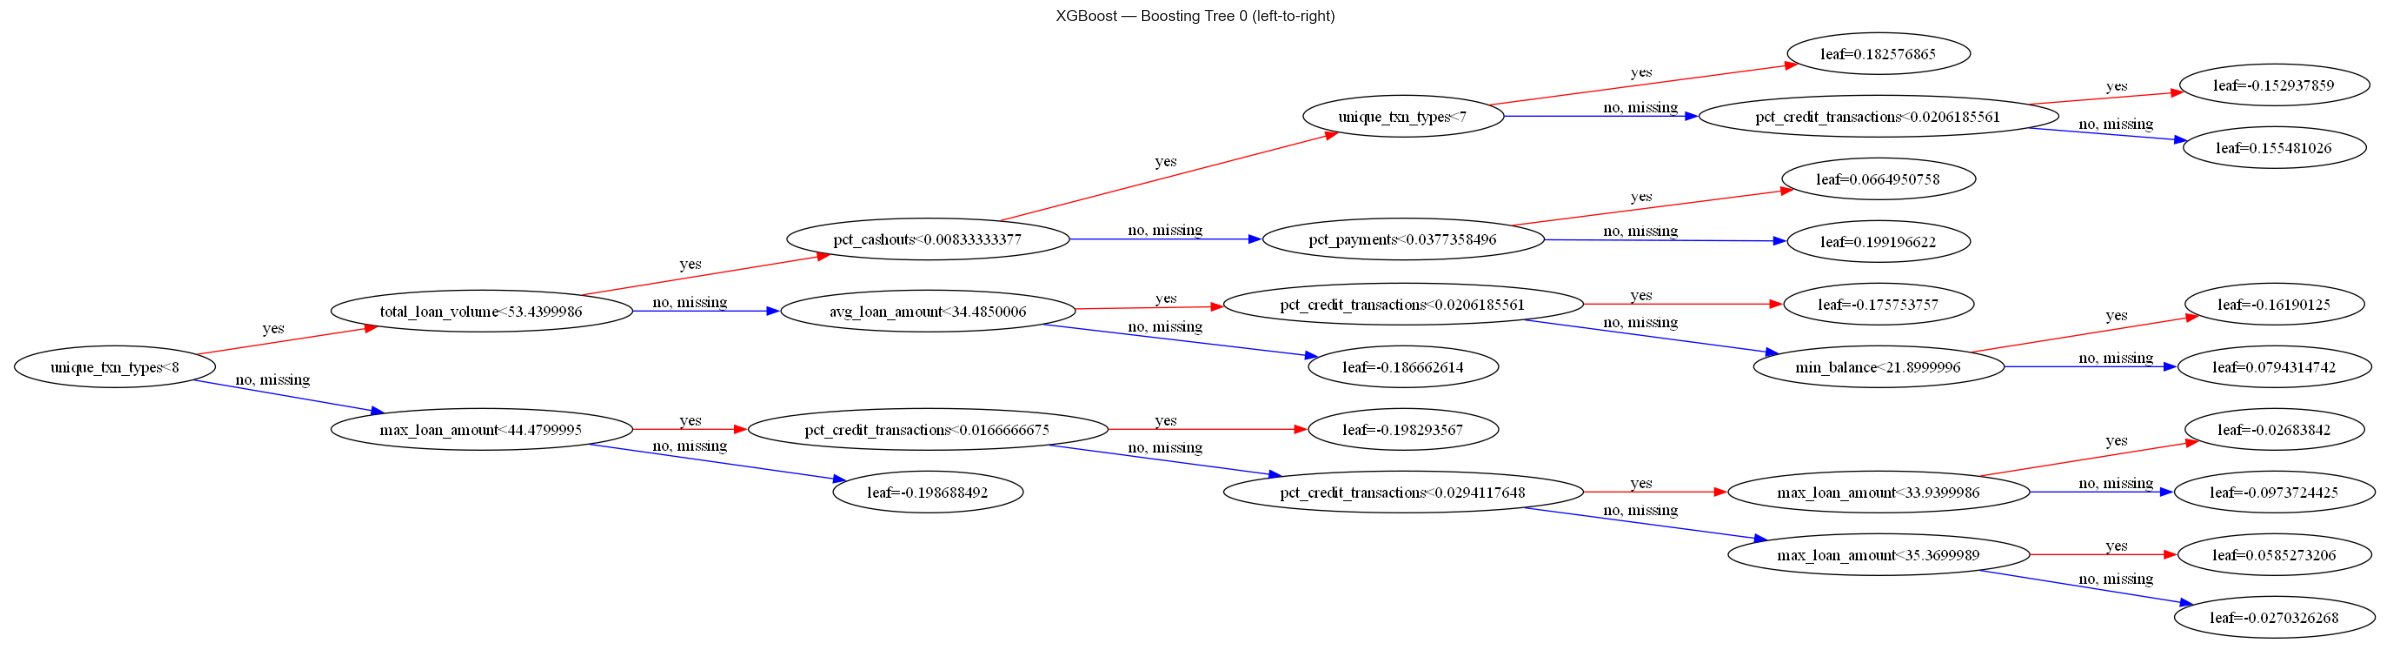

XGBoost tree 0 (text dump):
0:[unique_txn_types<8] yes=1,no=2,missing=2
	1:[total_loan_volume<53.4399986] yes=3,no=4,missing=4
		3:[pct_cashouts<0.00833333377] yes=7,no=8,missing=8
			7:[unique_txn_types<7] yes=13,no=14,missing=14
				13:leaf=0.182576865
				14:[pct_credit_transactions<0.0206185561] yes=21,no=22,missing=22
					21:leaf=-0.152937859
					22:leaf=0.155481026
			8:[pct_payments<0.0377358496] yes=15,no=16,missing=16
				15:leaf=0.0664950758
				16:leaf=0.199196622
		4:[avg_loan_amount<34.4850006] yes=9,no=10,missing=10
			9:[pct_credit_transactions<0.0206185561] yes=17,no=18,missing=18
				17:leaf=-0.175753757
				18:[min_balance<21.8999996] yes=23,no=24,missing=24
					23:leaf=-0.16190125
					24:leaf=0.0794314742
			10:leaf=-0.186662614
	2:[max_loan_amount<44.4799995] yes=5,no=6,missing=6
		5:[pct_credit_transactions<0.0166666675] yes=11,no=12,missing=12
			11:leaf=-0.198293567
			12:[pct_credit_transactions<0.0294117648] yes=19,no=20,missing=20
				19:[max_loan_amount<3

In [18]:
# XGBoost — plot boosting tree 0 using xgboost's matplotlib renderer
import xgboost as xgb

try:
    fig, ax = plt.subplots(figsize=(24, 12))
    xgb.plot_tree(xgb_model.model, num_trees=0, ax=ax, rankdir='LR')
    ax.set_title('XGBoost — Boosting Tree 0 (left-to-right)', fontsize=11)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'xgb.plot_tree unavailable ({e}); showing text dump instead.')

# Text dump for precise thresholds (always available)
tree_text = xgb_model.model.get_booster().get_dump(dump_format='text')[0]
print('XGBoost tree 0 (text dump):')
print(tree_text)


dot on PATH: C:\Program Files\Graphviz\bin\dot.EXE
python-graphviz module available


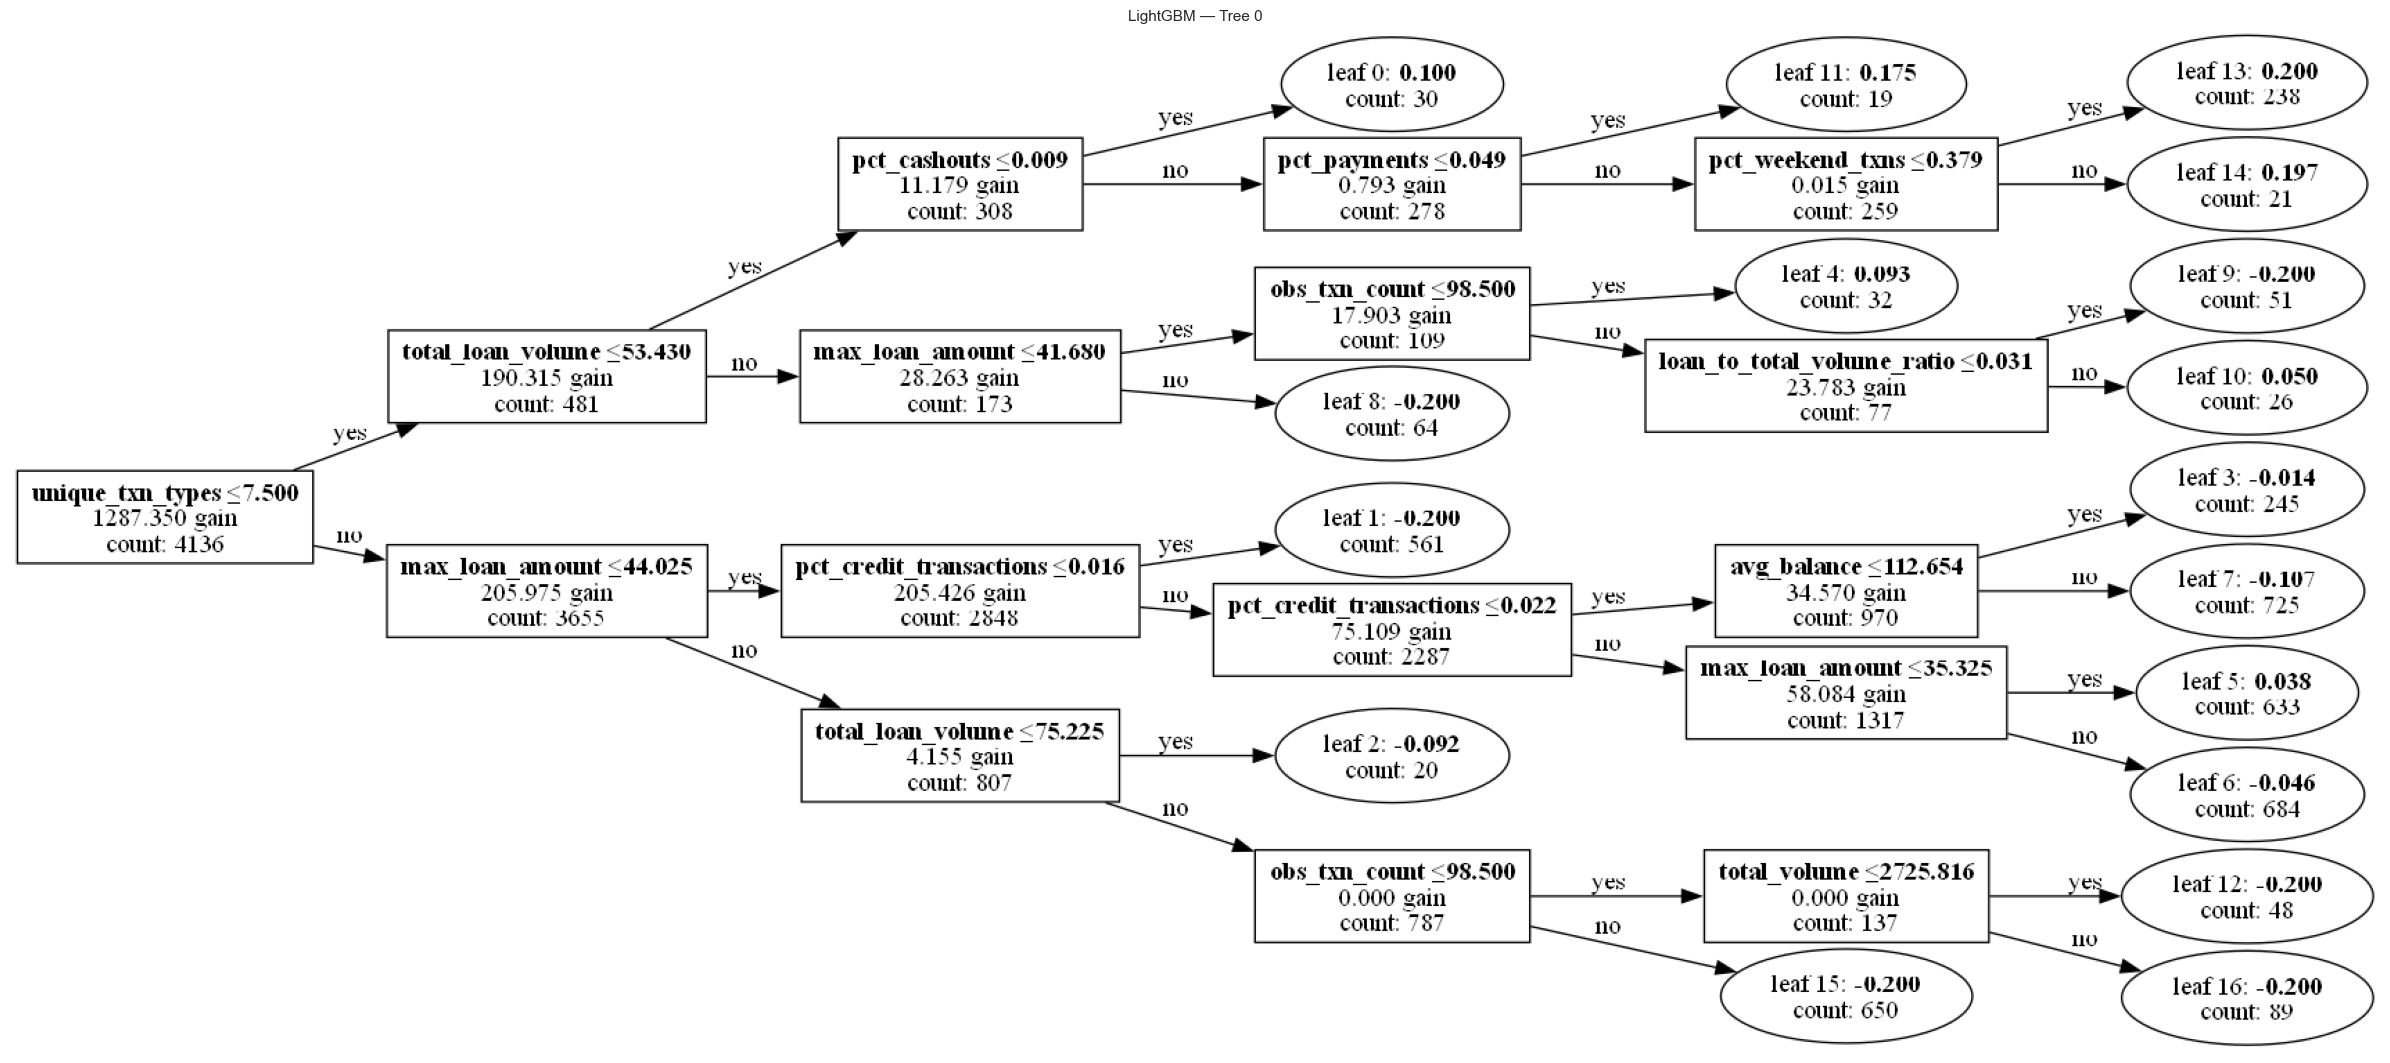

In [19]:
# LightGBM — plot tree 0
# lgb.plot_tree can cache a pre-Graphviz state; force-refresh plotting flags and fallback to text dump if needed
import os
import shutil
import importlib
import lightgbm as lgb
import lightgbm.plotting as lgb_plotting

graphviz_bin = r'C:\Program Files\Graphviz\bin'
if os.path.exists(os.path.join(graphviz_bin, 'dot.exe')) and graphviz_bin not in os.environ.get('PATH', ''):
    os.environ['PATH'] = graphviz_bin + os.pathsep + os.environ.get('PATH', '')

dot_path = shutil.which('dot')
print('dot on PATH:', dot_path)

# Refresh LightGBM plotting module in current kernel
lgb_plotting = importlib.reload(lgb_plotting)

try:
    import graphviz  # noqa: F401
    lgb_plotting.GRAPHVIZ_INSTALLED = True
    print('python-graphviz module available')
except Exception as e:
    print(f'python-graphviz module missing in kernel: {e}')

try:
    ax = lgb_plotting.plot_tree(
        lgbm_model.model, tree_index=0,
        figsize=(24, 12), show_info=['split_gain', 'internal_count', 'leaf_count'],
    )
    ax.set_title('LightGBM — Tree 0', fontsize=11)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'LightGBM graphical tree unavailable ({e}); showing text dump instead.')
    tree_info = lgbm_model.model.booster_.dump_model()['tree_info'][0]

    def _print_tree(node, indent=0):
        pad = '  ' * indent
        if 'split_feature' in node:
            fname = feature_names[node['split_feature']]
            print(f'{pad}if {fname} <= {node["threshold"]:.4f}  '
                  f'[gain={node["split_gain"]:.4f}, count={node["internal_count"]}]')
            _print_tree(node['left_child'],  indent + 1)
            _print_tree(node['right_child'], indent + 1)
        else:
            print(f'{pad}leaf value = {node["leaf_value"]:.4f}  [count={node["leaf_count"]}]')

    print('LightGBM tree 0:')
    _print_tree(tree_info['tree_structure'])


## 8. Model Calibration

A well-calibrated model's predicted probability of 0.3 should empirically correspond to
a 30% default rate in that probability bucket.  
**Brier score**: MSE of probability predictions (lower = better, 0 = perfect).  
**ECE (Expected Calibration Error)**: weighted mean |confidence - accuracy| across 15 bins.


In [20]:
def expected_calibration_error(y_true, y_prob, n_bins=15):
    bins = np.linspace(0, 1, n_bins + 1)
    ece, n = 0.0, len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0: continue
        ece += mask.sum() / n * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece

rows = []
for name, proba in zip(model_names, all_probas):
    rows.append({
        'Model':        name,
        'Brier Score':  round(brier_score_loss(y_test_lstm, proba), 4),
        'ECE (15 bins)':round(expected_calibration_error(y_test_lstm, proba), 4),
        'AUC-ROC':      round(roc_auc_score(y_test_lstm, proba), 4),
    })

df_calib = pd.DataFrame(rows).set_index('Model')
print('Calibration Metrics (y_default, test set):')
print(df_calib.to_string())


Calibration Metrics (y_default, test set):
                     Brier Score  ECE (15 bins)  AUC-ROC
Model                                                   
Logistic Regression       0.2243         0.2431   0.4794
XGBoost                   0.6537         0.7212   0.4587
Random Forest             0.1545         0.2010   0.4608
LightGBM                  0.7788         0.8154   0.4927
Seq LSTM                  0.2346         0.3537   0.5046
Hybrid LSTM               0.1299         0.2067   0.8627


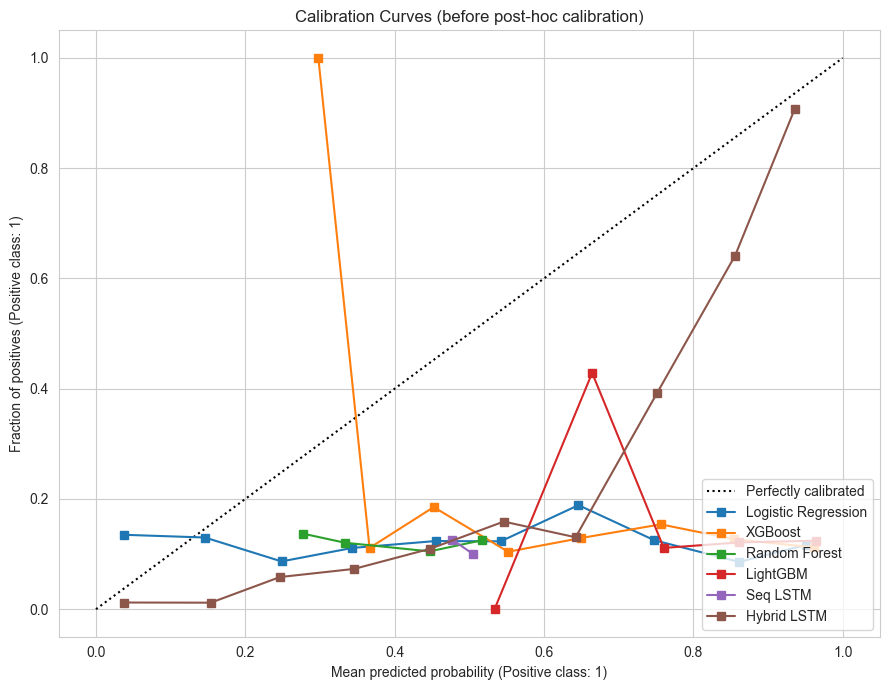

In [21]:
# Reliability diagrams (calibration curves)
fig, ax = plt.subplots(figsize=(9, 7))
for name, proba in zip(model_names, all_probas):
    CalibrationDisplay.from_predictions(y_test_lstm, proba, n_bins=10, ax=ax, name=name)
ax.set_title('Calibration Curves (before post-hoc calibration)')
plt.tight_layout()
plt.show()


In [22]:
# Post-hoc isotonic calibration: carve calibration split from training data
X_tr_cal, X_cal, y_tr_cal, y_cal = train_test_split(
    X_train_scaled, y_train,
    test_size=0.20, stratify=y_train, random_state=42,
)

def isotonic_calibrate(model, X_calib, y_calib, X_test_data):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(model.predict_proba(X_calib), y_calib)
    return ir.transform(model.predict_proba(X_test_data))

xgb_cal_proba  = isotonic_calibrate(xgb_model,  X_cal, y_cal, X_test_scaled)
lgbm_cal_proba = isotonic_calibrate(lgbm_model, X_cal, y_cal, X_test_scaled)
print('Isotonic calibration applied to XGBoost and LightGBM.')


Isotonic calibration applied to XGBoost and LightGBM.


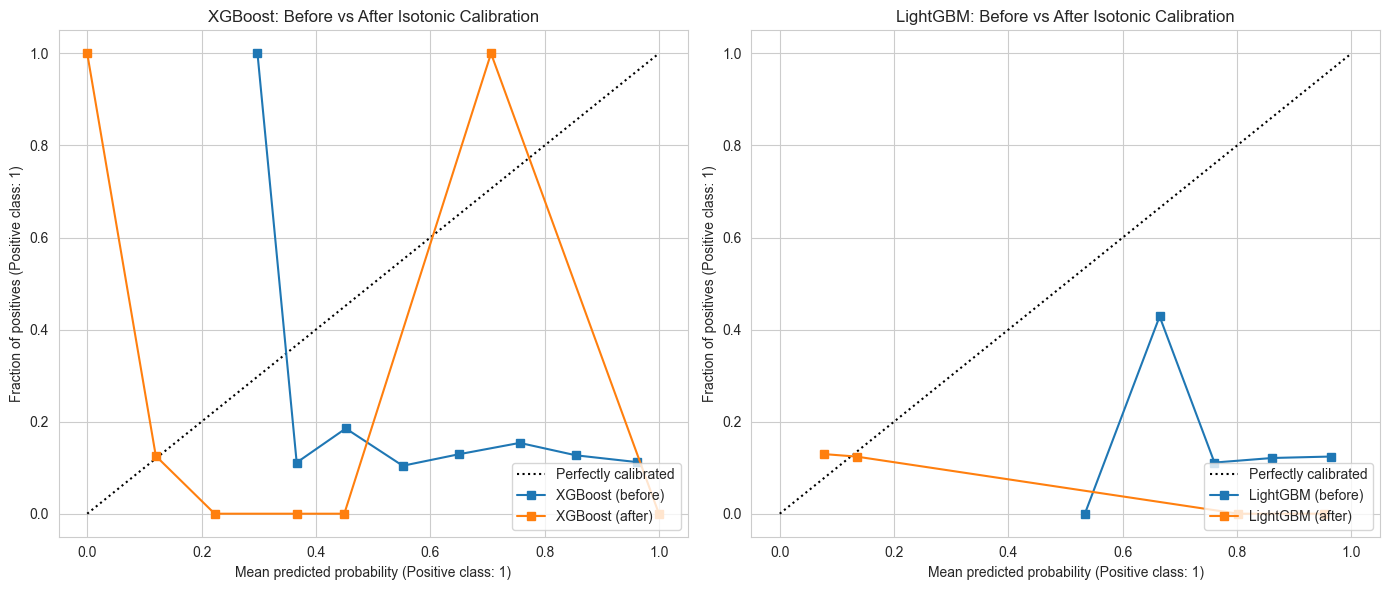

Post-hoc Calibration Summary:
          Brier (before)  Brier (after)  ECE (before)  ECE (after)  AUC-ROC (before)  AUC-ROC (after)
Model                                                                                                
XGBoost           0.6537         0.1110        0.7212       0.0199            0.4587           0.4765
LightGBM          0.7788         0.1121        0.8154       0.0103            0.4927           0.4961


In [23]:
# Before / after calibration curves + summary table
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pairs = [
    (axes[0], 'XGBoost',  xgb_proba,  xgb_cal_proba),
    (axes[1], 'LightGBM', lgbm_proba, lgbm_cal_proba),
]
for ax, name, before, after in pairs:
    CalibrationDisplay.from_predictions(y_test_lstm, before, n_bins=10, ax=ax, name=f'{name} (before)')
    CalibrationDisplay.from_predictions(y_test_lstm, after,  n_bins=10, ax=ax, name=f'{name} (after)')
    ax.set_title(f'{name}: Before vs After Isotonic Calibration')
plt.tight_layout()
plt.show()

post_rows = []
for name, before, after in [('XGBoost', xgb_proba, xgb_cal_proba),
                              ('LightGBM', lgbm_proba, lgbm_cal_proba)]:
    post_rows.append({
        'Model':           name,
        'Brier (before)':  round(brier_score_loss(y_test_lstm, before), 4),
        'Brier (after)':   round(brier_score_loss(y_test_lstm, after),  4),
        'ECE (before)':    round(expected_calibration_error(y_test_lstm, before), 4),
        'ECE (after)':     round(expected_calibration_error(y_test_lstm, after),  4),
        'AUC-ROC (before)':round(roc_auc_score(y_test_lstm, before), 4),
        'AUC-ROC (after)': round(roc_auc_score(y_test_lstm, after),  4),
    })
print('Post-hoc Calibration Summary:')
print(pd.DataFrame(post_rows).set_index('Model').to_string())
